# Raw (before-WZA) mirror Manhattans — SNP vs non-SNP (pooled), LFMM, clq0.9 TILING, all 20 axes

Successor to `raw_manhattan_snp_vs_nonsnp_lfmm.ipynb`, which used the **strict** clq0.9
partition (interval containment) — that partition drops 39.7% of SNP / 49.3% of SV /
40.7% of non-SNP records that fall in inter-block gaps. This version uses the
**tiling** reblocking (`reblock_blockdef.py --how tiling`, HapFM's gap-free rule): every
record keeps a block, same LD boundaries, **0% dropped**.

Per-record `wza_in_clq09_tile` p-values (the input WZA aggregates, not the block-level
output) — one figure per climate axis (bio1-19 + pc1), LFMM only. SNP up, nonsnp down.
Dashed = per-class Bonferroni (0.05/n records). Vertical dotted line + gene label = a
tiling block whose lead nonsnp record is Bonferroni-sig while its lead SNP record in the
same block is not ("new" peak, first-pass — not yet checked for SNP-tagging).

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/r2_gea_nonsnp/phase1_replication/results/multiaxis/wza_in_clq09_tile"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MODEL = "lfmm"
CLS = "nonsnp"
CHROM_LEN = {"Chr1":30427671,"Chr2":19698289,"Chr3":23459830,"Chr4":18585056,"Chr5":26975502}
CH = list(CHROM_LEN); OFF = {}; _a = 0
for _c in CH: OFF[_c] = _a; _a += CHROM_LEN[_c]
plt.rcParams.update({"figure.dpi":110})
SNP_DARK, SNP_LIGHT = "#495057", "#ADB5BD"
CLS_DARK  = "#c0392b" if CLS == "sv" else "#1B5E20"
CLS_LIGHT = "#e8a58c" if CLS == "sv" else "#66BB6A"

def block_spans_tiling(r2=0.9):
    """Tiling block spans: each block absorbs the preceding gap (matches reblock_blockdef.py)."""
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch = f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i-1]) + 1
            hi = int(ends[i]) if i < len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")
SPANS=block_spans_tiling(); GENES=lib.load_genes()
def genes_on(block):
    if block not in SPANS.index: return []
    s=SPANS.loc[block]; gc=GENES[(GENES.chrom==s.chrom)&(GENES.end>=s.start)&(GENES.start<=s.end)]
    return list(gc.gene)
print("loaded:", len(SPANS), "tiling blocks,", len(GENES), "genes ; class =", CLS)

loaded: 58376 tiling blocks, 27206 genes ; class = nonsnp


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


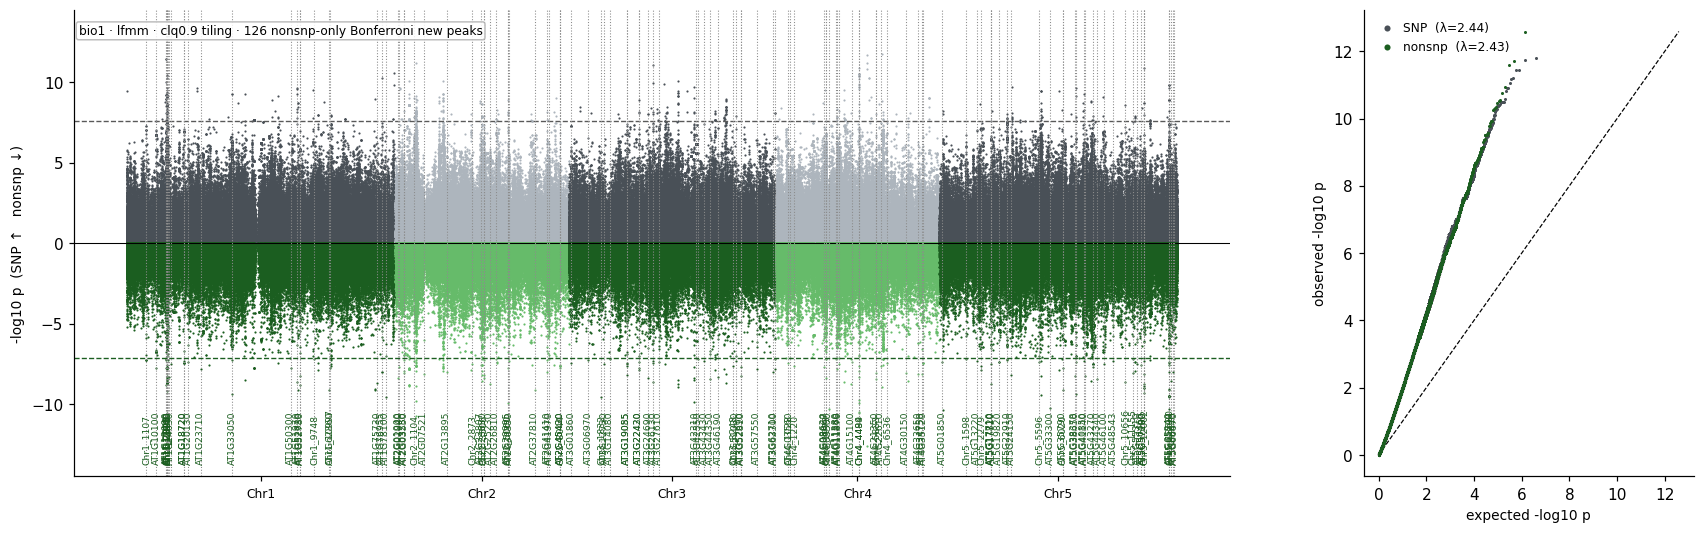

bio1: 126 nonsnp-only Bonferroni new peaks (gene-bearing: 98)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
36287,Chr5_2856,Chr5,5839507,AT5G17710,11.715833,5.934316
26105,Chr4_2065,Chr4,6017308,AT4G09500,10.290787,3.047926
38600,Chr5_5726,Chr5,12566156,AT5G33300,10.266015,2.277662
27944,Chr4_4489,Chr4,9445784,,9.937552,6.987126
14597,Chr2_5060,Chr2,12774729,,9.921858,4.026477
...,...,...,...,...,...,...
16516,Chr2_7420,Chr2,17525868,AT2G41970,7.177822,0.928456
34937,Chr5_13842,Chr5,26614551,AT5G66670,7.170525,6.095020
26518,Chr4_2614,Chr4,6863482,AT4G11280,7.161031,4.519603
25358,Chr4_1155,Chr4,1590843,AT4G03560;AT4G03565;AT4G03566;AT4G03570;AT4G03...,7.153027,5.791175


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


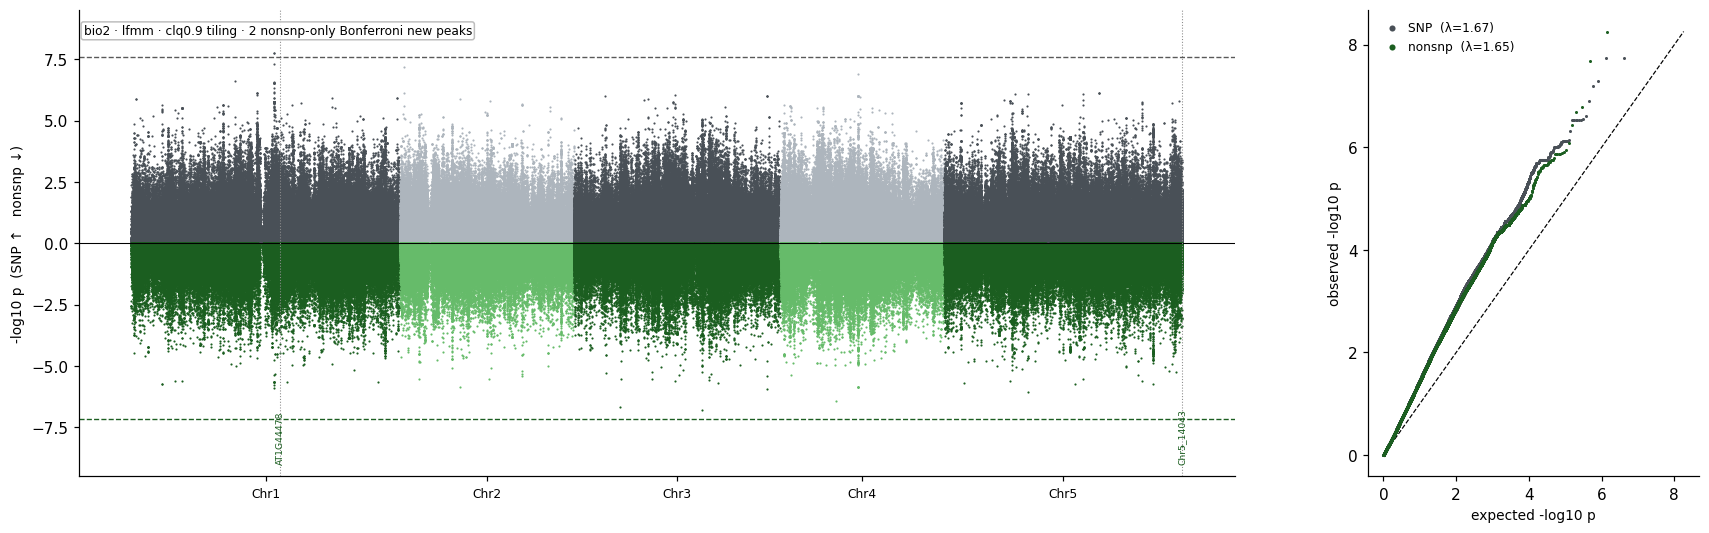

bio2: 2 nonsnp-only Bonferroni new peaks (gene-bearing: 1)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
35099,Chr5_14043,Chr5,26917409,,8.259275,2.007397
9282,Chr1_7471,Chr1,16866149,AT1G44478;AT1G44542,7.692412,1.343415


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


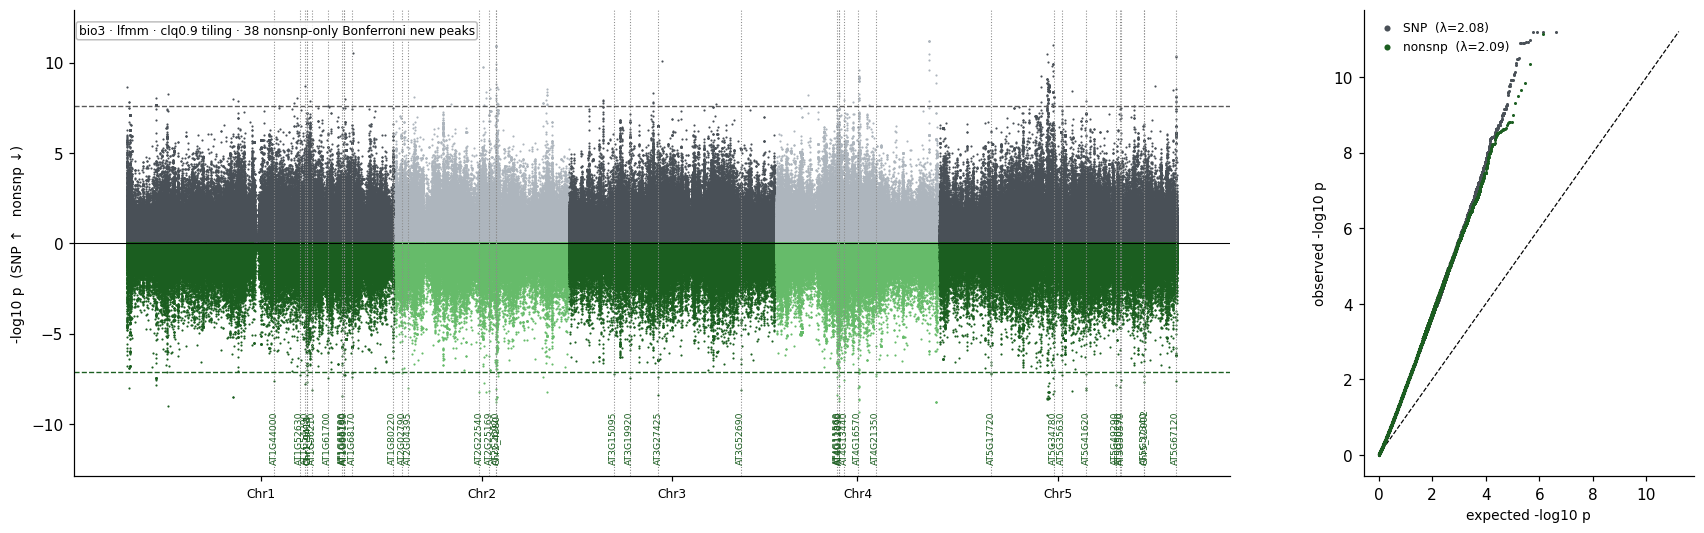

bio3: 38 nonsnp-only Bonferroni new peaks (gene-bearing: 34)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
13975,Chr2_4298,Chr2,11490838,AT2G26920;AT2G26930,10.351155,4.026028
13962,Chr2_4280,Chr2,11443305,,8.609947,4.332043
1815,Chr1_12318,Chr1,24470448,AT1G65790;AT1G65800,8.470373,3.906755
21514,Chr3_5436,Chr3,10152052,AT3G27425;AT3G27430,8.423492,6.486046
26615,Chr4_2733,Chr4,7003747,AT4G11560,8.368656,6.492310
13161,Chr2_3257,Chr2,9581106,AT2G22540,8.229052,3.105176
13665,Chr2_3905,Chr2,10719536,AT2G25169;AT2G25170;AT2G25180,8.196432,6.747671
38620,Chr5_5750,Chr5,12960302,AT5G34780;AT5G34830,8.191202,6.518942
24256,Chr3_8756,Chr3,19533160,AT3G52690;AT3G52700;AT3G52710,8.135748,5.222767
11049,Chr1_9632,Chr1,21037928,AT1G56210,8.105530,5.108167


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


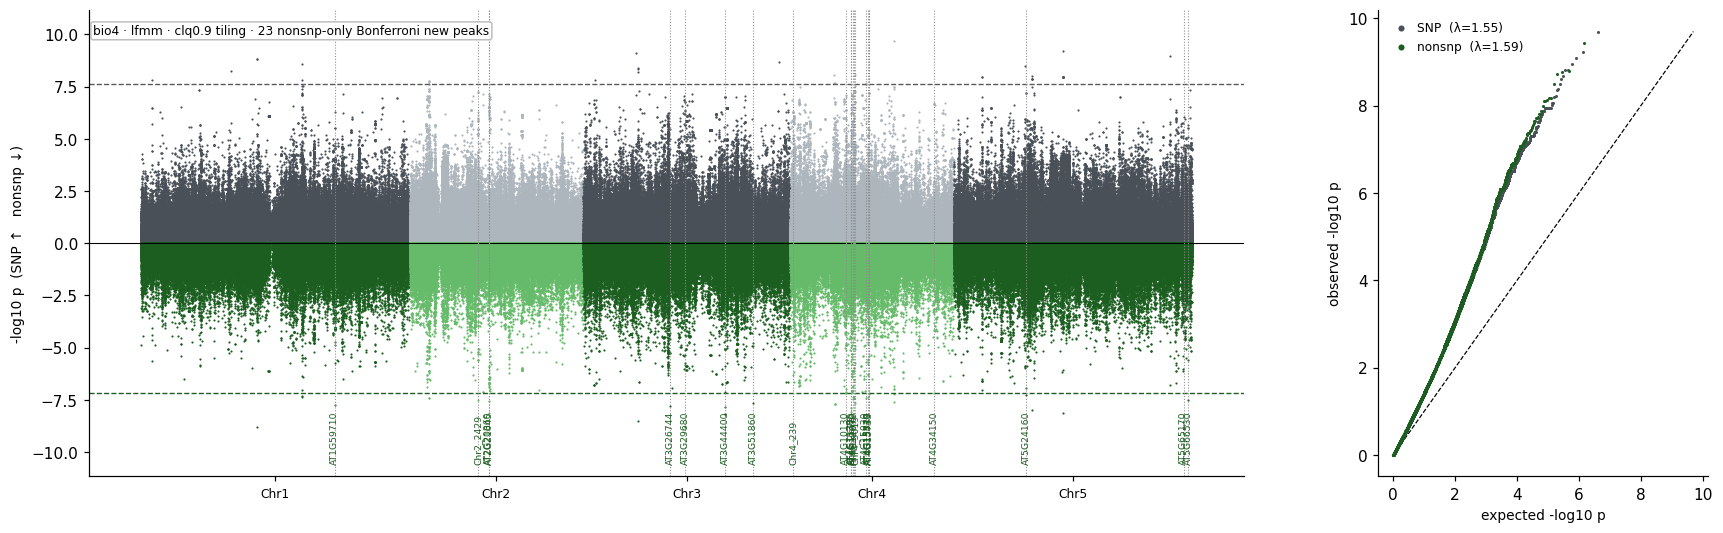

bio4: 23 nonsnp-only Bonferroni new peaks (gene-bearing: 19)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
26358,Chr4_239,Chr4,312232,,9.428398,6.263378
22022,Chr3_6063,Chr3,11530078,AT3G29680;AT3G29690,8.797301,6.773539
34680,Chr5_13511,Chr5,26042512,AT5G65170,8.724841,6.037537
22558,Chr3_6648,Chr3,16066101,AT3G44400;AT3G44428;AT3G44430;AT3G44440,8.180383,6.996577
12946,Chr2_2981,Chr2,9032070,AT2G21045,8.109678,2.223119
26563,Chr4_2672,Chr4,6927138,AT4G11385;AT4G11390,8.100379,5.434539
26566,Chr4_2675,Chr4,6934090,,7.887167,2.276622
21357,Chr3_5231,Chr3,9836707,AT3G26744,7.813856,1.953356
159,Chr1_10184,Chr1,21939211,AT1G59710,7.752649,2.492218
24123,Chr3_8600,Chr3,19243848,AT3G51860;AT3G51870;AT3G51880;AT3G51890;AT3G51895,7.651619,3.316786


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


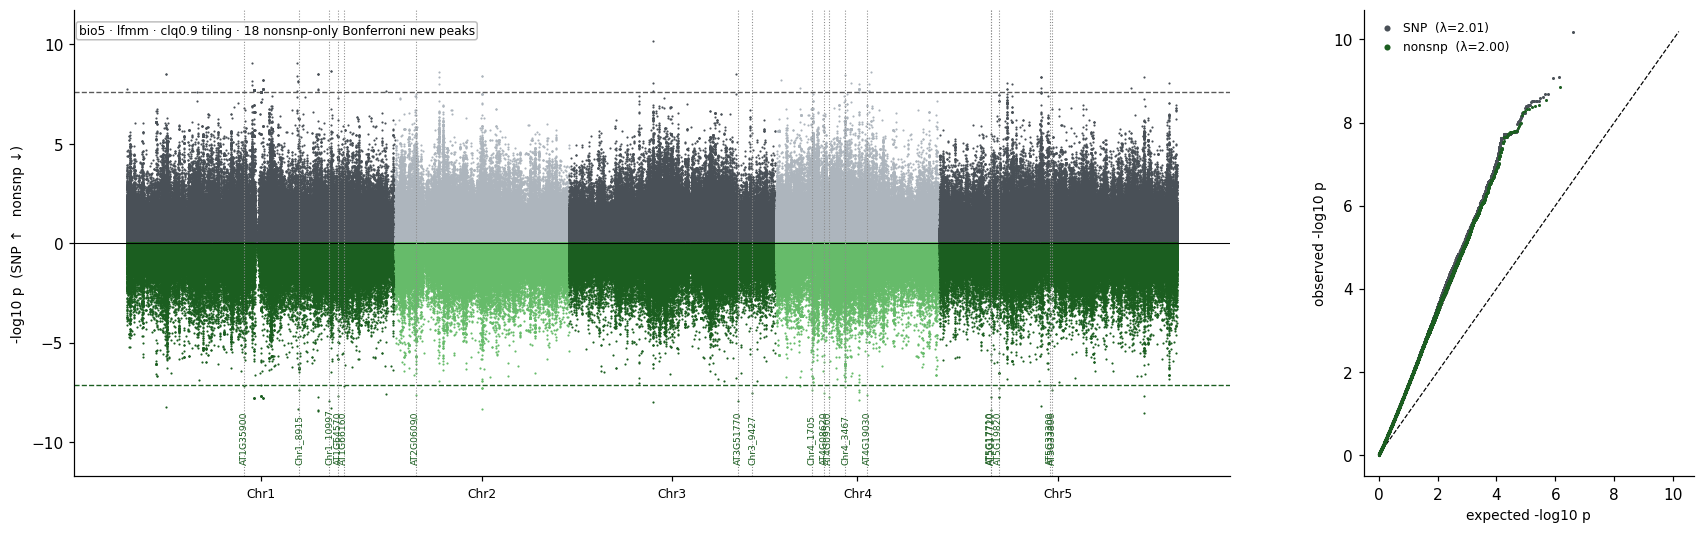

bio5: 18 nonsnp-only Bonferroni new peaks (gene-bearing: 13)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
11502,Chr2_1202,Chr2,2367872,AT2G06090;AT2G06095,8.847444,7.515997
36292,Chr5_2867,Chr5,5845643,AT5G17720;AT5G17730;AT5G17740;AT5G17750,8.403650,5.515742
24116,Chr3_8594,Chr3,19212510,AT3G51770;AT3G51780;AT3G51790;AT3G51800,7.955156,2.276326
791,Chr1_10997,Chr1,22978065,,7.928128,1.547657
36647,Chr5_3308,Chr5,6703242,AT5G19820;AT5G19830;AT5G19840;AT5G19850,7.743875,7.476739
36287,Chr5_2856,Chr5,5839507,AT5G17710,7.726301,3.284012
26105,Chr4_2065,Chr4,6017308,AT4G09500,7.708751,2.131224
1498,Chr1_11895,Chr1,23978154,AT1G64570;AT1G64580;AT1G64583,7.671018,7.331385
28507,Chr4_5223,Chr4,10422792,AT4G19030,7.649204,6.883321
25988,Chr4_1914,Chr4,5502965,AT4G08620,7.541869,5.842464


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


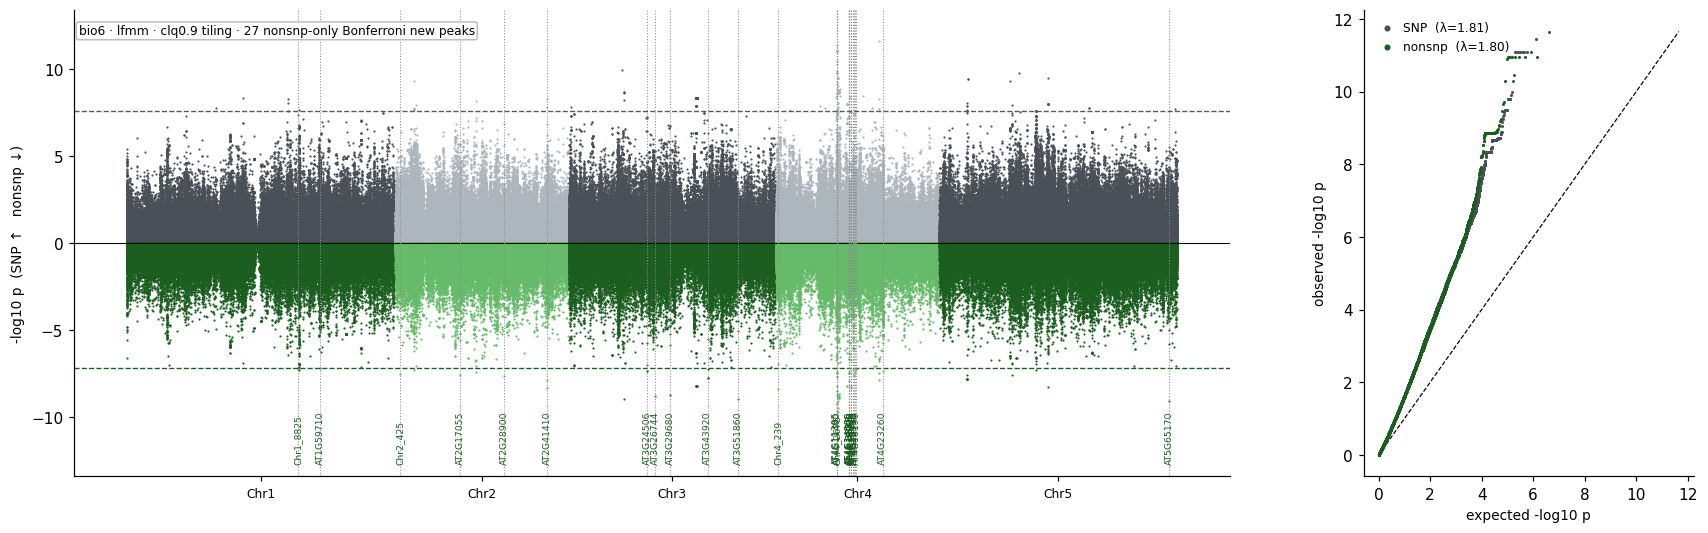

bio6: 27 nonsnp-only Bonferroni new peaks (gene-bearing: 20)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
26604,Chr4_2720,Chr4,6978538,AT4G11490,10.945029,2.562796
26563,Chr4_2672,Chr4,6927138,AT4G11385;AT4G11390,9.177935,7.417804
34680,Chr5_13511,Chr5,26042512,AT5G65170,9.076091,3.749799
24123,Chr3_8600,Chr3,19243848,AT3G51860;AT3G51870;AT3G51880;AT3G51890;AT3G51895,8.978319,3.013455
21357,Chr3_5231,Chr3,9836707,AT3G26744,8.794865,2.122537
22022,Chr3_6063,Chr3,11530078,AT3G29680;AT3G29690,8.752511,6.765707
26358,Chr4_239,Chr4,312232,,8.365223,4.236881
27507,Chr4_3930,Chr4,8524299,,8.304941,2.136970
26566,Chr4_2675,Chr4,6934090,,8.199841,3.296069
27528,Chr4_3961,Chr4,8584950,AT4G15030;AT4G15040,8.198757,2.558834


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


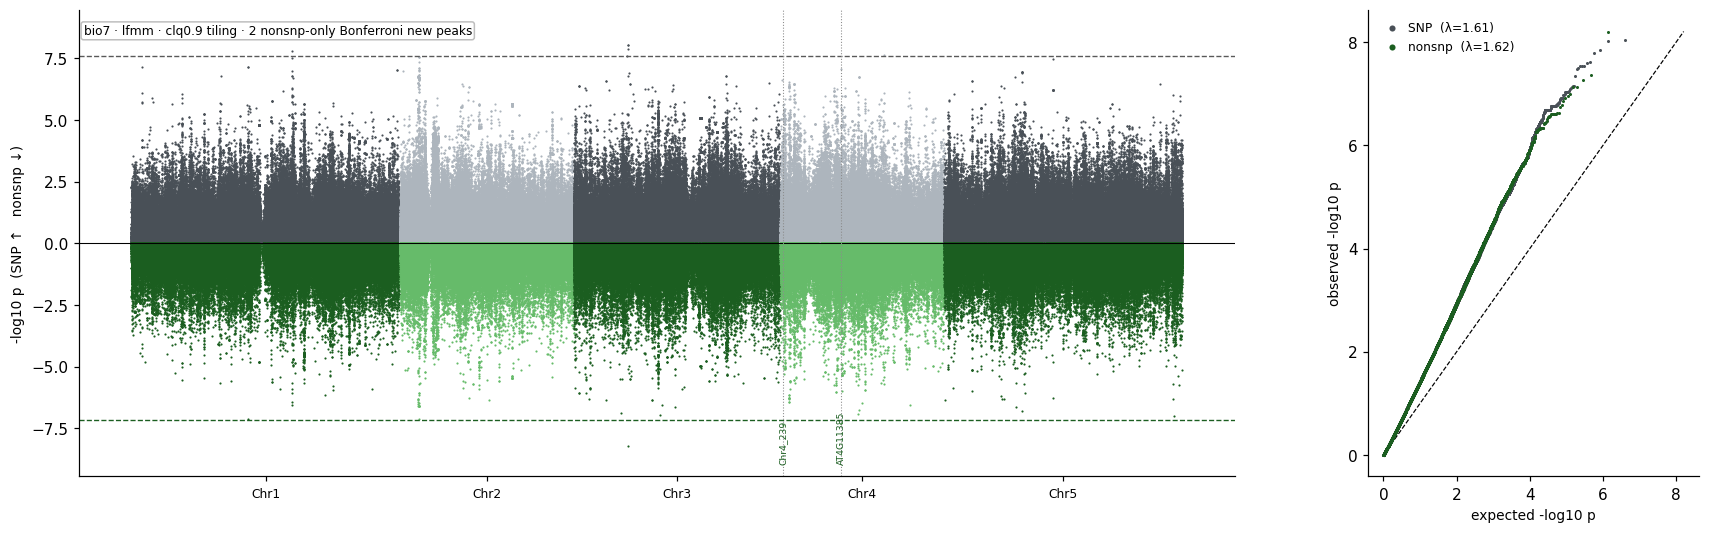

bio7: 2 nonsnp-only Bonferroni new peaks (gene-bearing: 1)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
26358,Chr4_239,Chr4,312232,,7.370152,5.032737
26563,Chr4_2672,Chr4,6927138,AT4G11385;AT4G11390,7.276251,4.807047


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


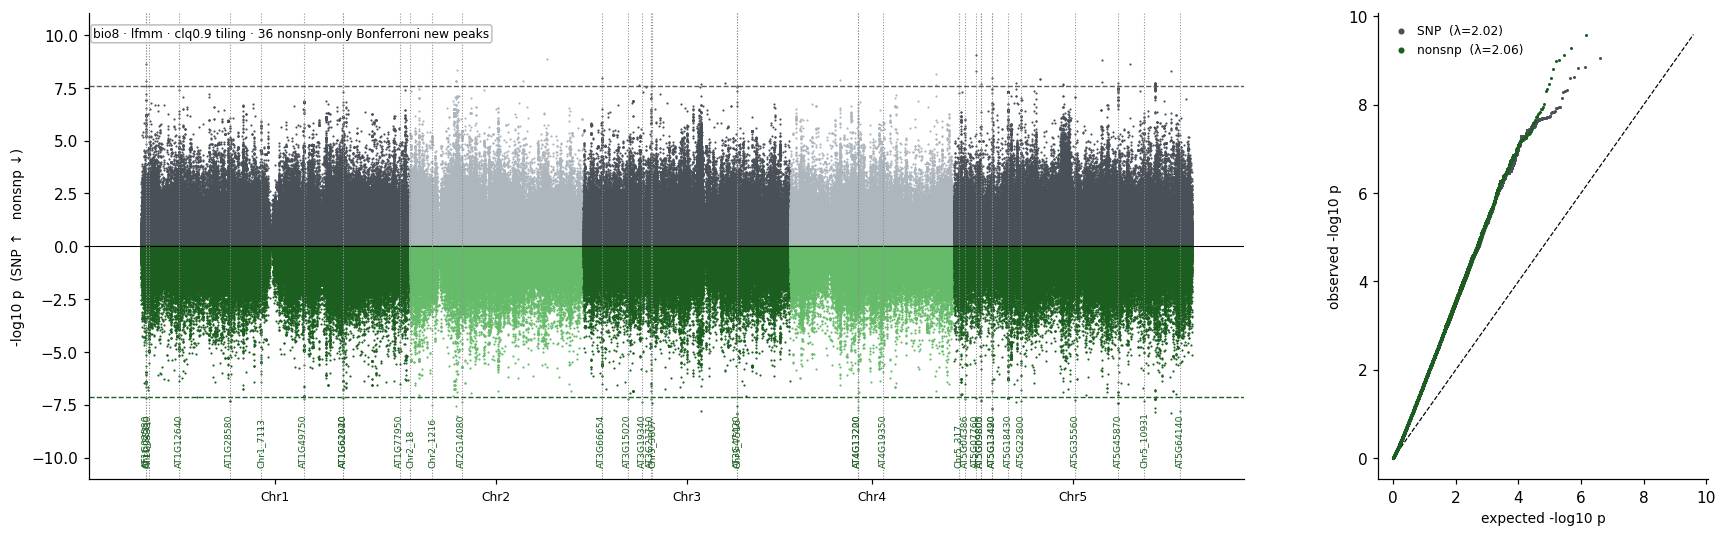

bio8: 36 nonsnp-only Bonferroni new peaks (gene-bearing: 28)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
4189,Chr1_15307,Chr1,29310647,AT1G77950;AT1G77960,9.586898,3.305268
36540,Chr5_317,Chr5,507788,,9.273157,1.993862
730,Chr1_10915,Chr1,22887230,AT1G61920,9.112628,6.810283
5973,Chr1_331,Chr1,549823,,9.013522,7.585968
28589,Chr4_5331,Chr4,10562980,AT4G19350,8.987113,5.880994
18085,Chr3_1105,Chr3,2092282,AT3G66654;AT3G66656,8.797788,5.606892
8986,Chr1_7113,Chr1,13565477,,8.607662,2.595200
35731,Chr5_2146,Chr5,4337749,AT5G13490;AT5G13500,8.470788,6.518780
7137,Chr1_481,Chr1,835766,AT1G03330;AT1G03340;AT1G03350;AT1G03360;AT1G03...,8.358552,4.169578
5017,Chr1_2132,Chr1,4305681,AT1G12640;AT1G12650,8.319151,7.385193


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


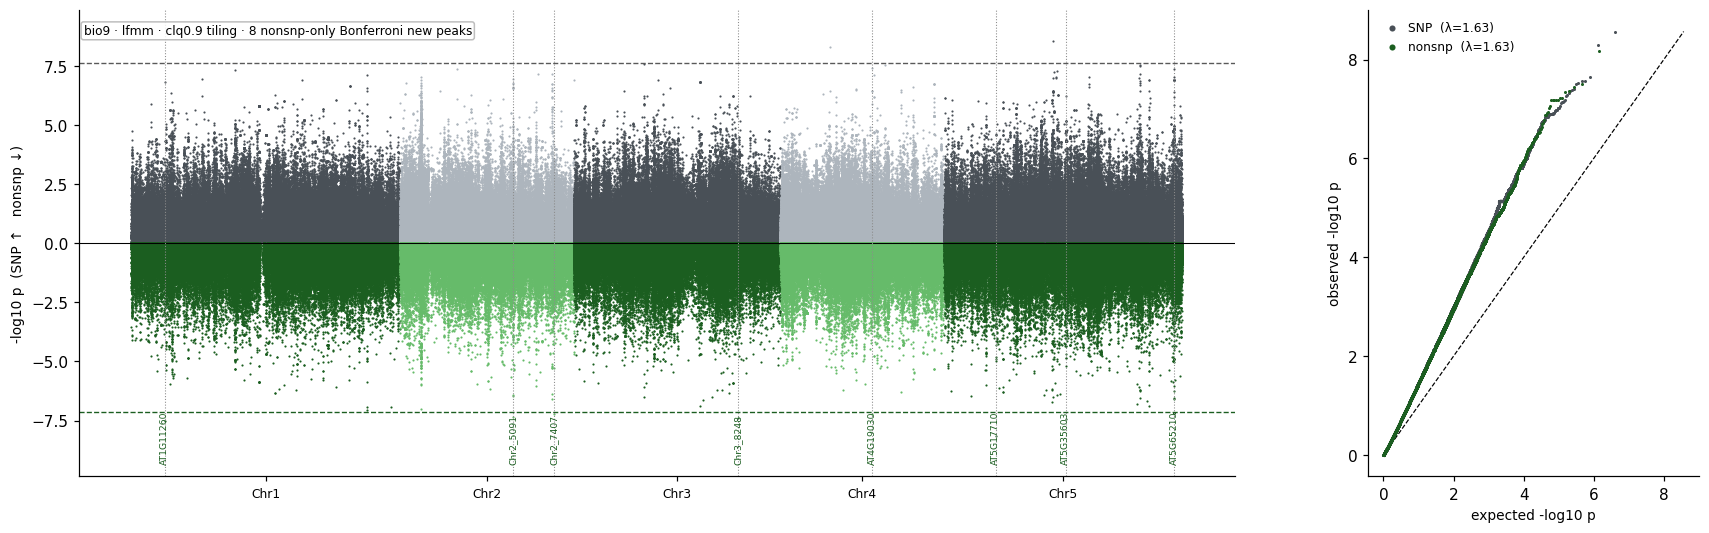

bio9: 8 nonsnp-only Bonferroni new peaks (gene-bearing: 5)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
36287,Chr5_2856,Chr5,5839507,AT5G17710,8.163670,2.888269
4742,Chr1_1782,Chr1,3778874,AT1G11260,7.504711,6.824106
38778,Chr5_5941,Chr5,13776873,AT5G35603;AT5G35604,7.437842,6.234289
23835,Chr3_8248,Chr3,18660261,,7.372591,1.550922
14620,Chr2_5091,Chr2,12805666,,7.344693,6.730456
28507,Chr4_5223,Chr4,10422792,AT4G19030,7.217731,6.430457
16502,Chr2_7407,Chr2,17488957,,7.213604,3.163905
34697,Chr5_13532,Chr5,26071027,AT5G65210;AT5G65220;AT5G65230,7.190538,7.366416


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


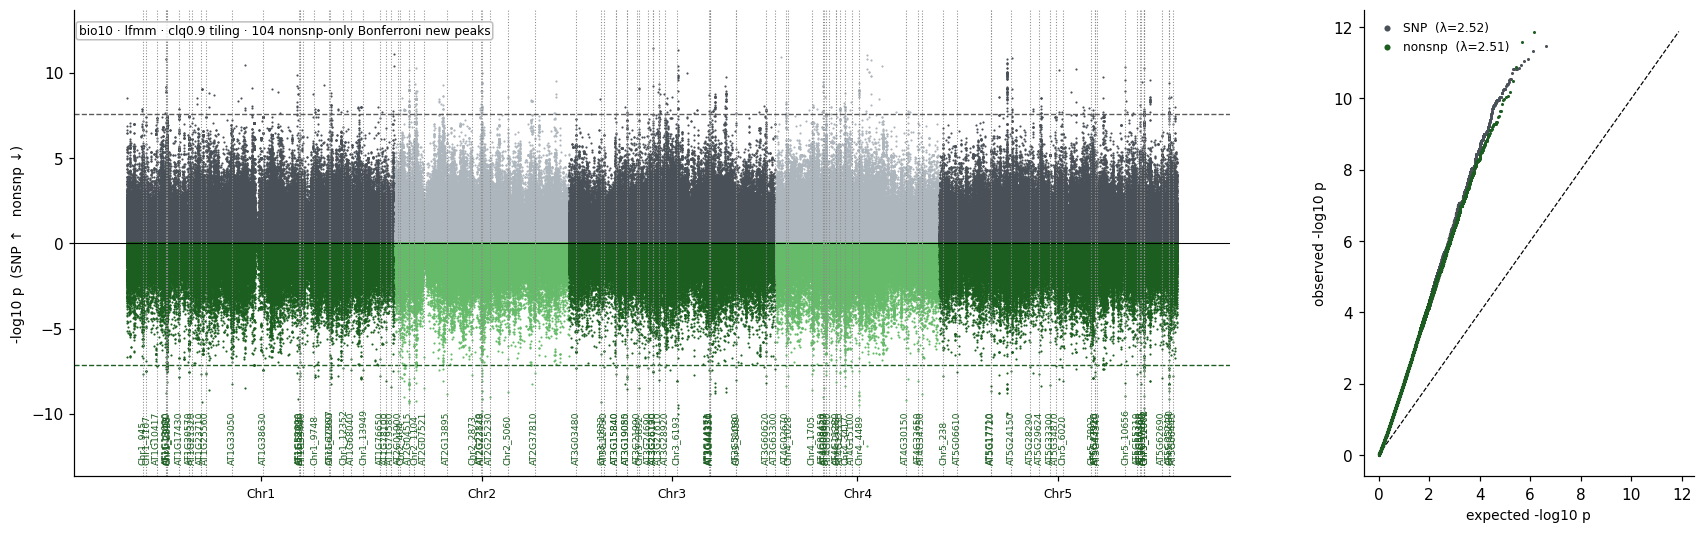

bio10: 104 nonsnp-only Bonferroni new peaks (gene-bearing: 75)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
791,Chr1_10997,Chr1,22978065,,11.582619,1.499531
26105,Chr4_2065,Chr4,6017308,AT4G09500,10.176766,3.566928
18657,Chr3_1832,Chr3,3692367,,9.332931,4.503931
30342,Chr4_7532,Chr4,14741994,AT4G30150,9.194023,3.140029
25942,Chr4_1855,Chr4,5370156,AT4G08450,9.006653,5.225534
...,...,...,...,...,...,...
13214,Chr2_3314,Chr2,9721648,AT2G22820,7.164323,7.599220
33446,Chr5_11972,Chr5,23175695,AT5G57190,7.163178,7.460214
17464,Chr2_917,Chr2,1574788,AT2G04515;AT2G04520,7.162040,4.337774
40812,Chr5_8576,Chr5,17860553,AT5G44340;AT5G44345;AT5G44350,7.154423,4.529355


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


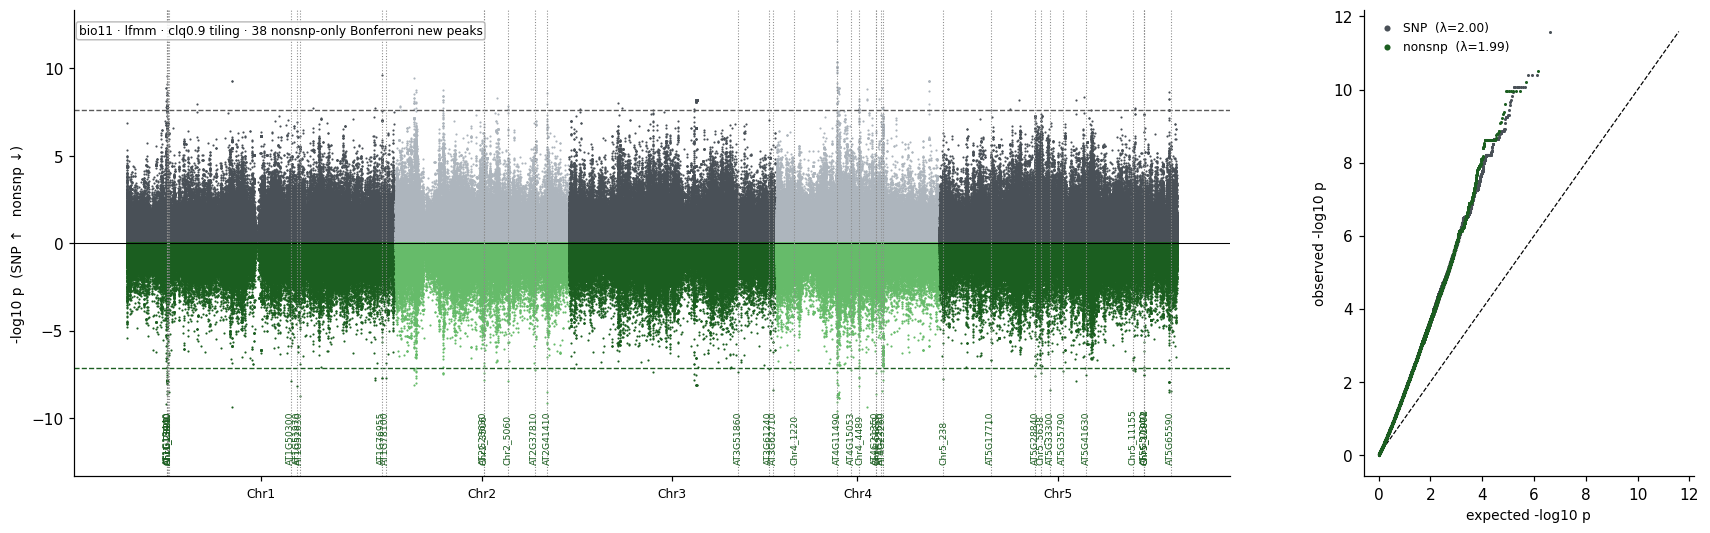

bio11: 38 nonsnp-only Bonferroni new peaks (gene-bearing: 26)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
36287,Chr5_2856,Chr5,5839507,AT5G17710,10.198638,4.601146
26604,Chr4_2720,Chr4,6978538,AT4G11490,9.964811,3.370140
16422,Chr2_7314,Chr2,17262984,AT2G41410;AT2G41415;AT2G41420,9.122993,1.973822
10485,Chr1_8922,Chr1,19610530,AT1G52630;AT1G52640,8.753841,2.703543
28986,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,8.632987,4.123557
5222,Chr1_2391,Chr1,4767022,AT1G13940,8.518092,6.287139
34738,Chr5_13585,Chr5,26214149,AT5G65590,8.458207,2.373077
38600,Chr5_5726,Chr5,12566156,AT5G33300,8.394056,2.263713
17977,Chr3_10571,Chr3,23198308,AT3G62710,8.393905,3.571230
10352,Chr1_8770,Chr1,19317379,AT1G51970,8.158240,3.095110


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


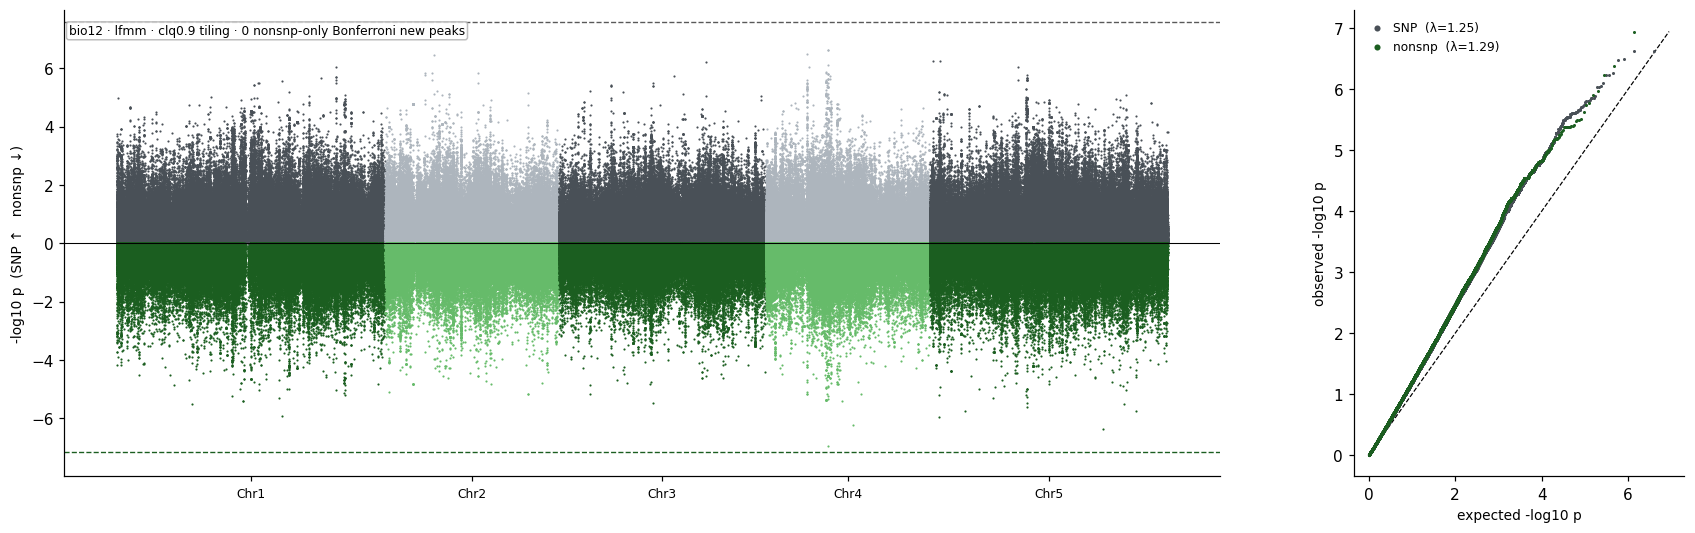

bio12: 0 nonsnp-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


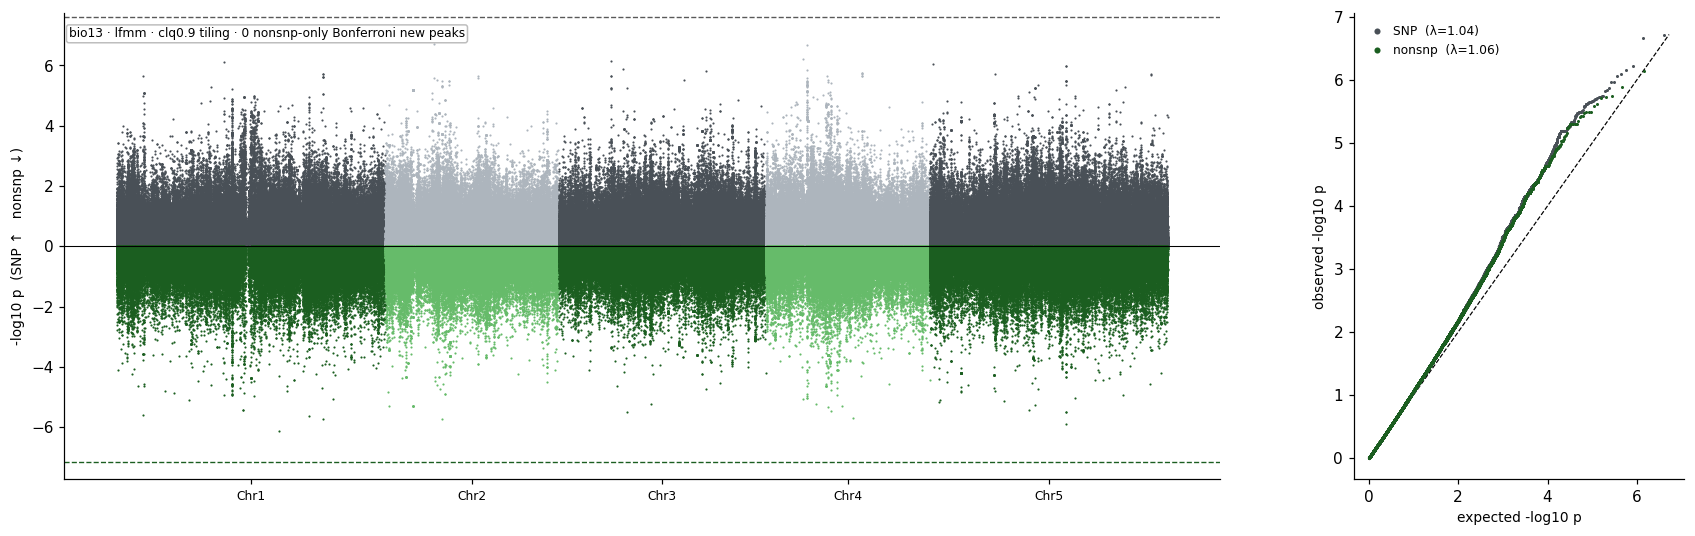

bio13: 0 nonsnp-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


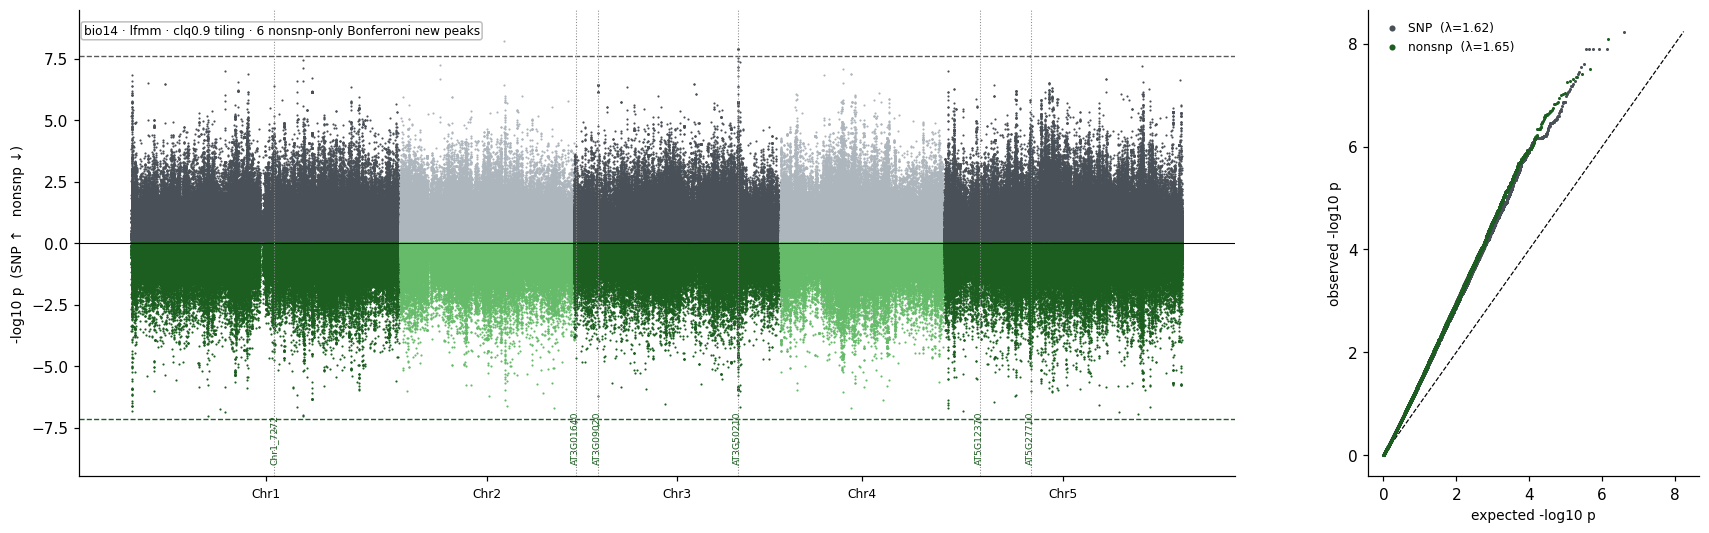

bio14: 6 nonsnp-only Bonferroni new peaks (gene-bearing: 5)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
23809,Chr3_8210,Chr3,18618085,AT3G50210;AT3G50220,8.091042,7.541707
9121,Chr1_7272,Chr1,16138770,,7.511262,2.870981
18275,Chr3_1355,Chr3,2756848,AT3G09020;AT3G09030;AT3G09032,7.408994,1.923300
38231,Chr5_5307,Chr5,9815510,AT5G27710;AT5G27720,7.306315,4.574752
35626,Chr5_2012,Chr5,4002967,AT5G12370,7.272005,2.715104
18195,Chr3_126,Chr3,241516,AT3G01640;AT3G01650,7.249896,2.387376


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


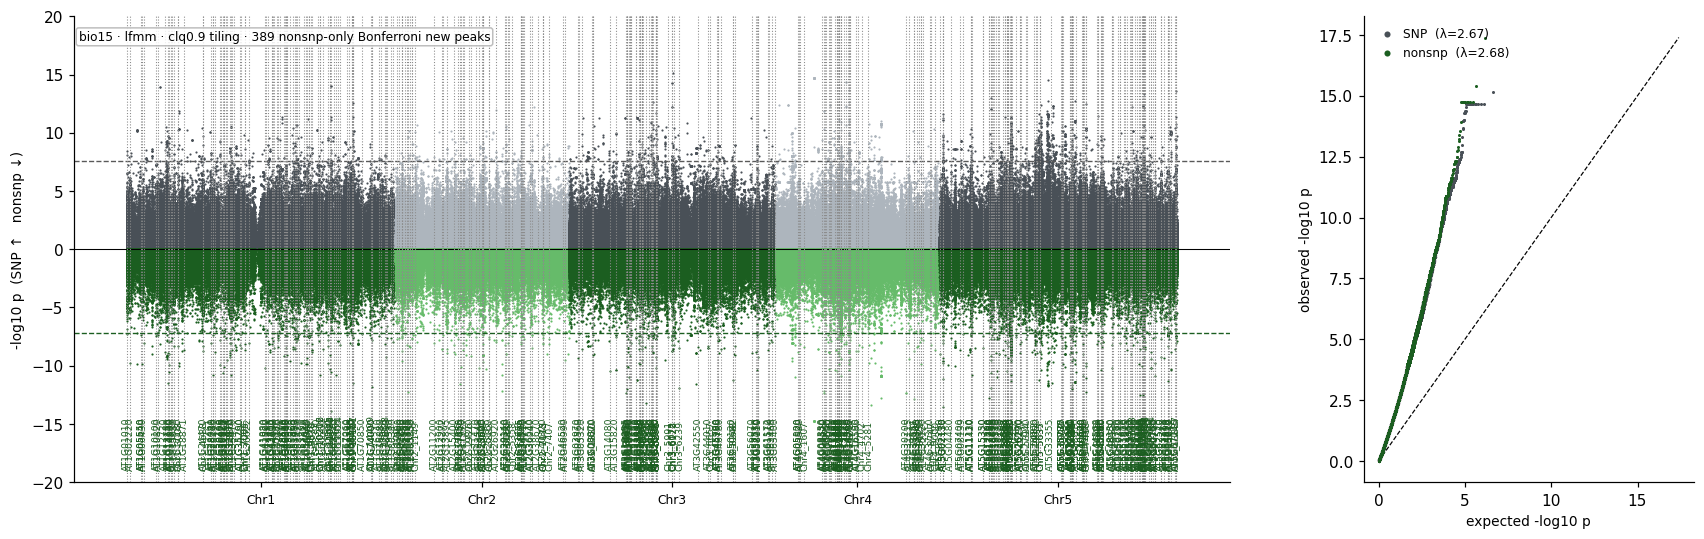

bio15: 389 nonsnp-only Bonferroni new peaks (gene-bearing: 302)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
20705,Chr3_4363,Chr3,8718434,AT3G24140,13.223576,6.350765
30569,Chr4_7809,Chr4,15673995,,12.895441,0.632223
36200,Chr5_2736,Chr5,5656471,AT5G17200;AT5G17210;AT5G17220,12.742852,3.842232
33258,Chr5_11748,Chr5,22801826,AT5G56300;AT5G56310,12.491333,6.320518
33424,Chr5_11945,Chr5,23114464,AT5G57110,12.487582,6.150216
...,...,...,...,...,...,...
22084,Chr3_6128,Chr3,11905197,,7.157588,3.601122
182,Chr1_10212,Chr1,21967048,,7.157478,7.229956
8966,Chr1_7095,Chr1,13457710,,7.154672,4.933434
15976,Chr2_6776,Chr2,16173200,AT2G38670,7.152088,2.284980


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


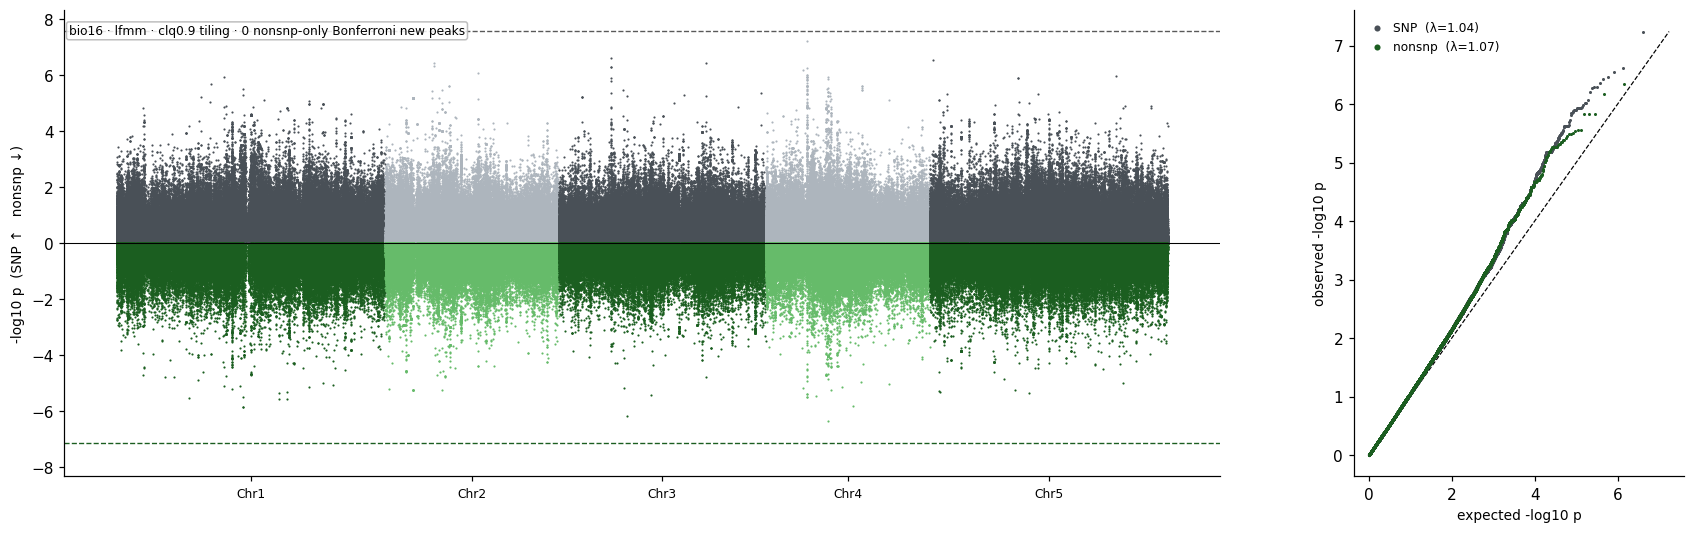

bio16: 0 nonsnp-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


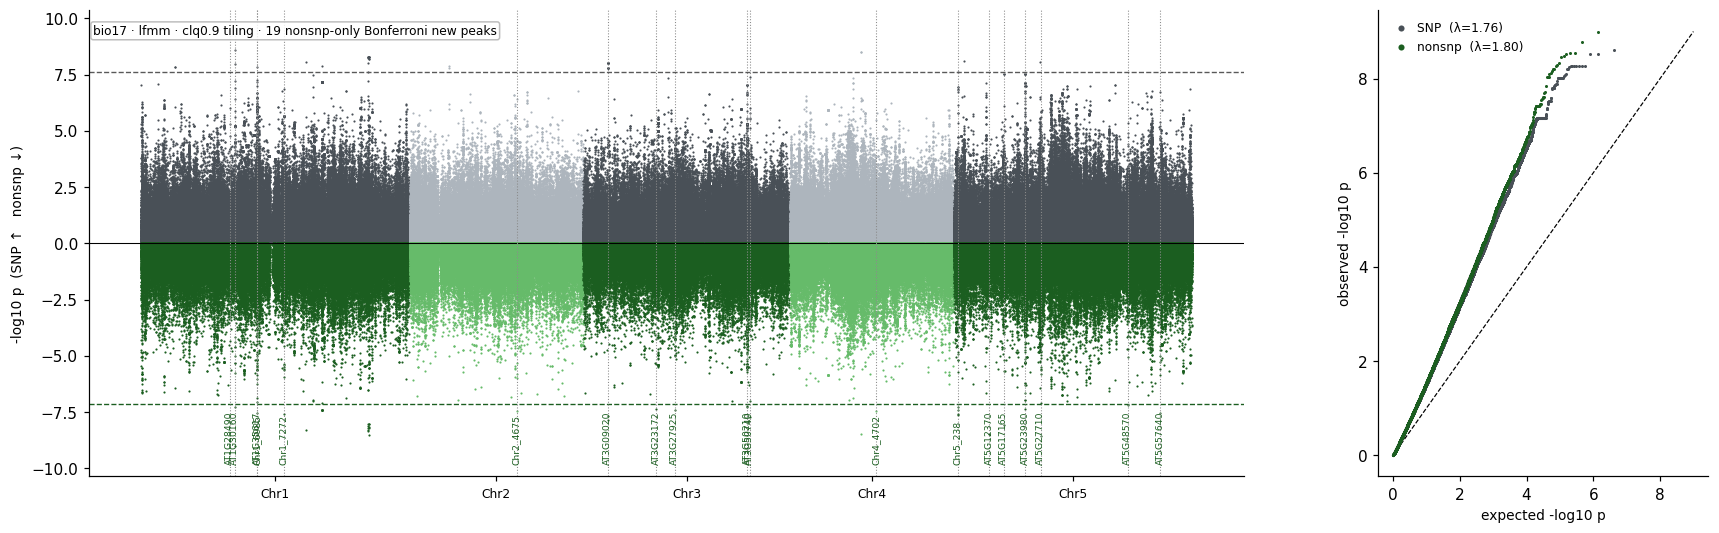

bio17: 19 nonsnp-only Bonferroni new peaks (gene-bearing: 14)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
7566,Chr1_5352,Chr1,10022462,AT1G28490;AT1G28500,8.775842,4.206200
38231,Chr5_5307,Chr5,9815510,AT5G27710;AT5G27720,8.553026,5.227288
8879,Chr1_6985,Chr1,13154736,,8.539636,4.701394
35626,Chr5_2012,Chr5,4002967,AT5G12370,8.476855,3.934489
36187,Chr5_2716,Chr5,5643343,AT5G17165,8.098387,7.501813
18275,Chr3_1355,Chr3,2756848,AT3G09020;AT3G09030;AT3G09032,7.849670,2.339602
23940,Chr3_8371,Chr3,18853470,AT3G50740;AT3G50750,7.715794,5.994095
35920,Chr5_238,Chr5,394192,,7.614578,7.597613
9121,Chr1_7272,Chr1,16138770,,7.579810,2.926926
8878,Chr1_6984,Chr1,13154163,AT1G35617,7.558265,6.470815


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


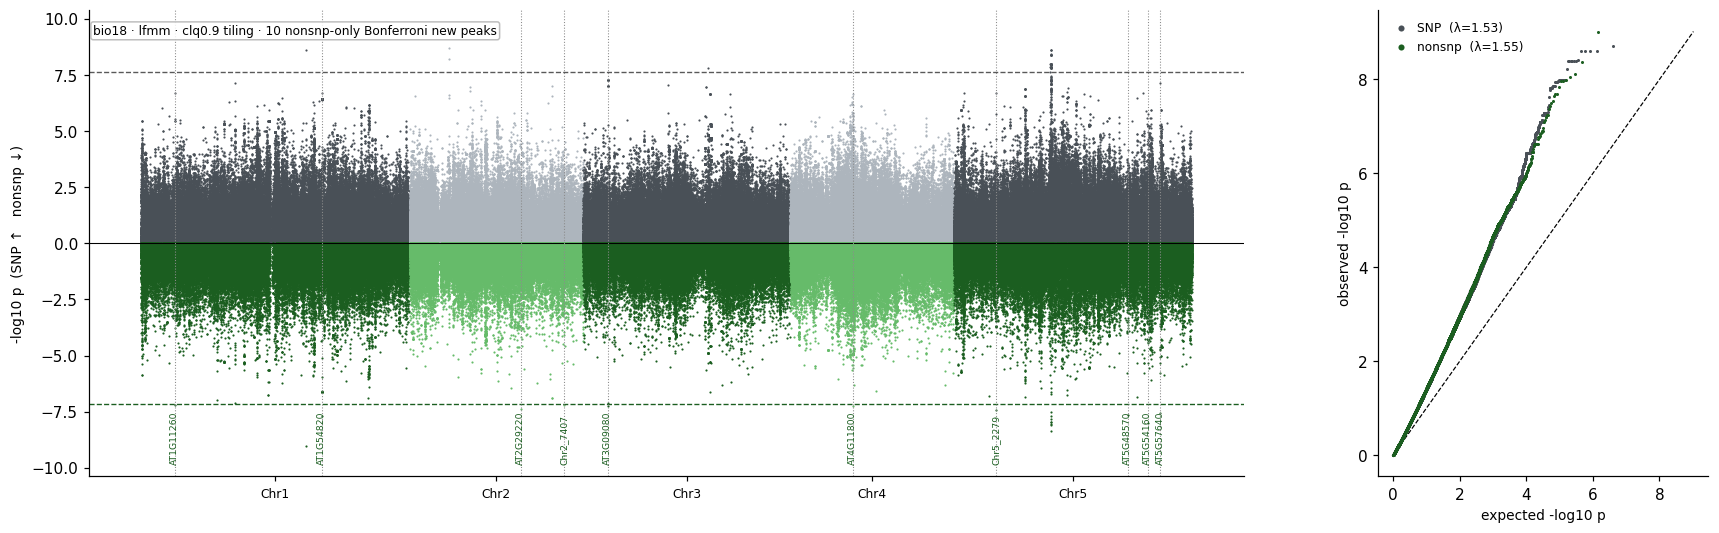

bio18: 10 nonsnp-only Bonferroni new peaks (gene-bearing: 8)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
32837,Chr5_11226,Chr5,21979915,AT5G54160,7.986718,3.030516
10869,Chr1_9404,Chr1,20466410,AT1G54820;AT1G54830;AT1G54840;AT1G54850;AT1G54...,7.687578,6.681454
41828,Chr5_9891,Chr5,19695454,AT5G48570;AT5G48575,7.641655,2.797133
33505,Chr5_12044,Chr5,23346212,AT5G57640;AT5G57650,7.546942,7.140647
35835,Chr5_2279,Chr5,4737524,,7.431727,6.706488
14531,Chr2_4978,Chr2,12581465,AT2G29220;AT2G29250;AT2G29260;AT2G29263;AT2G29290,7.363579,2.498635
18281,Chr3_1361,Chr3,2780819,AT3G09080,7.250588,7.279033
26671,Chr4_2825,Chr4,7100110,AT4G11800,7.236431,6.625837
4742,Chr1_1782,Chr1,3778874,AT1G11260,7.203141,6.680907
16502,Chr2_7407,Chr2,17488957,,7.196173,3.517764


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


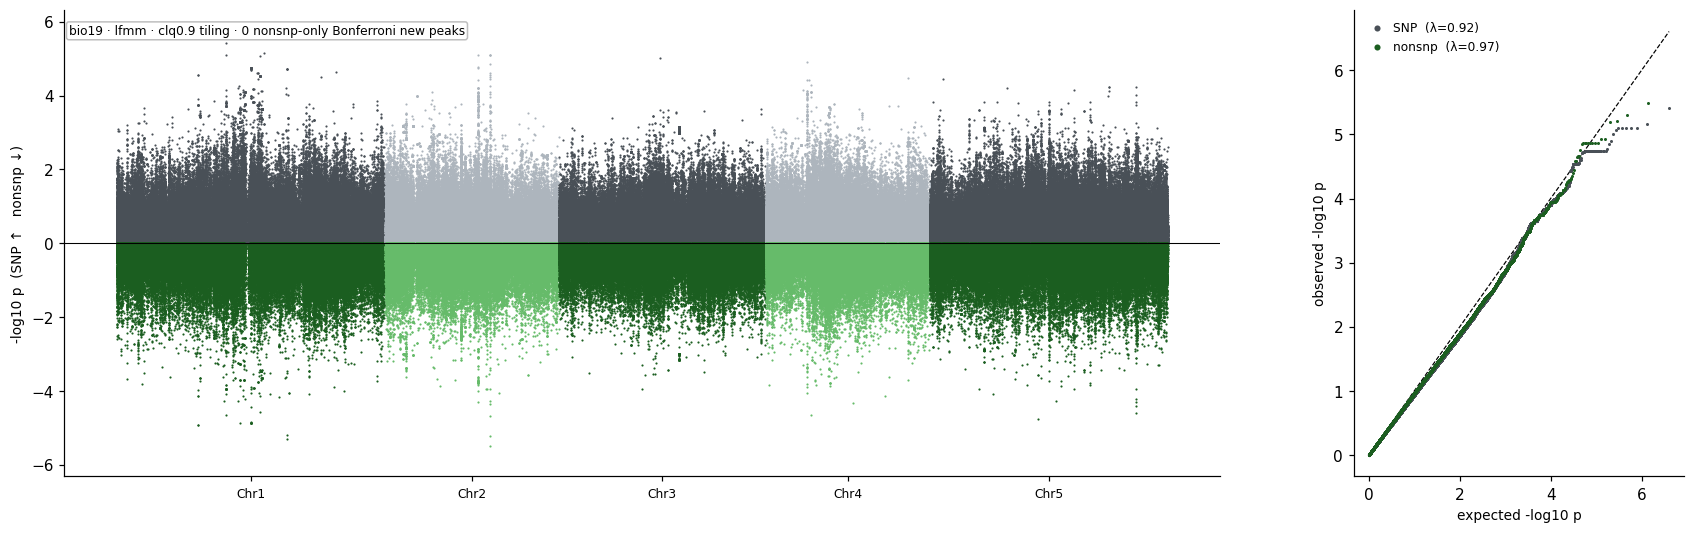

bio19: 0 nonsnp-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_2439790/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


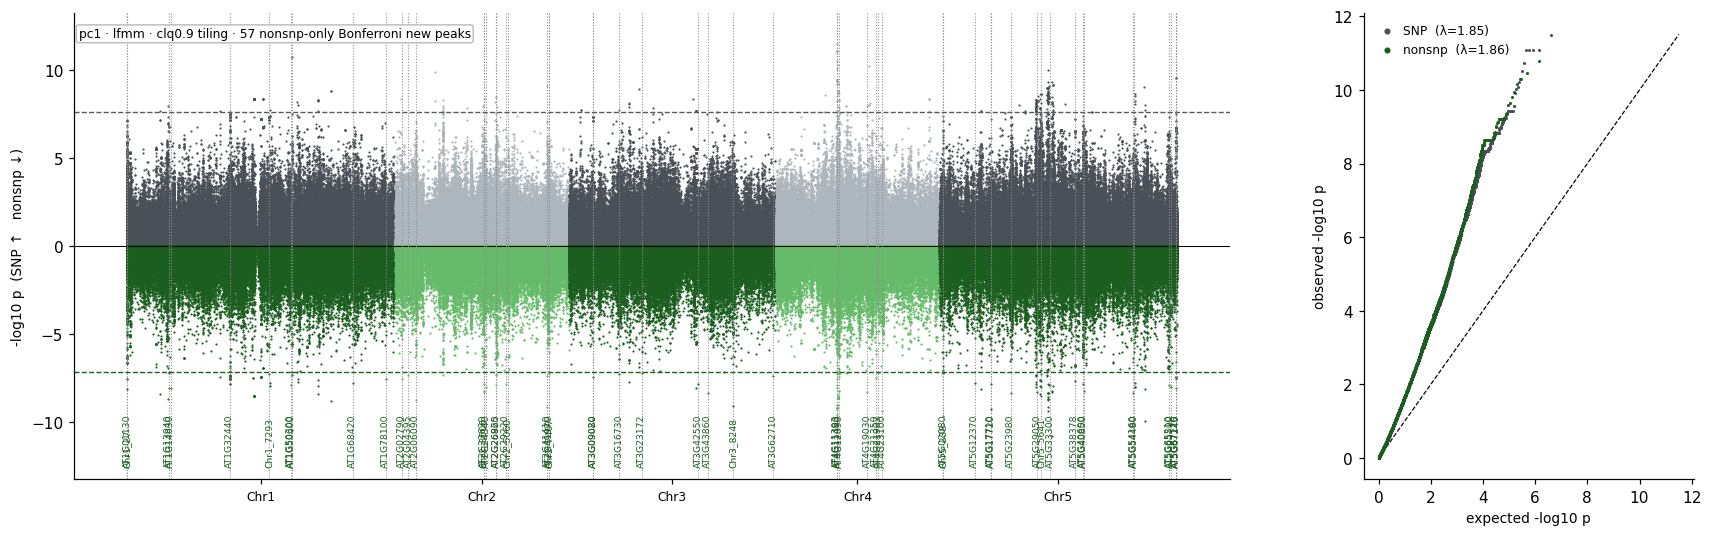

pc1: 57 nonsnp-only Bonferroni new peaks (gene-bearing: 49)


,block,chrom,pos,genes,nonsnp_nlp,snp_nlp_here
16502,Chr2_7407,Chr2,17488957,,10.282393,4.264273
18275,Chr3_1355,Chr3,2756848,AT3G09020;AT3G09030;AT3G09032,9.799067,2.957289
35920,Chr5_238,Chr5,394564,,9.647462,6.569153
29336,Chr4_6271,Chr4,12103235,AT4G23100,9.350884,6.707677
36287,Chr5_2856,Chr5,5839507,AT5G17710,9.257594,4.229166
26604,Chr4_2720,Chr4,6978538,AT4G11490,9.200119,3.811293
23835,Chr3_8248,Chr3,18660261,,9.087833,2.095438
14597,Chr2_5060,Chr2,12774729,,8.859376,2.629362
11502,Chr2_1202,Chr2,2369863,AT2G06090;AT2G06095,8.754449,7.121418
32837,Chr5_11226,Chr5,21979915,AT5G54160,8.347240,2.402417


In [2]:
from scipy import stats

def load_raw(cls, axis):
    f = f"{WZAIN}/{MODEL}_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f)
    d = d[d["MAF"] > 0.05].copy()
    d["nlp"] = -np.log10(d["pval"].clip(lower=1e-300))
    d["gpos"] = d["chrom"].map(OFF) + d["pos"]
    return d

def leads(d):
    d = d[d["block"].notna() & (d["block"] != "")]
    return d.loc[d.groupby("block")["nlp"].idxmax()]

def gif_lambda(p):
    # genomic inflation factor: median observed chi2(1df) / expected median (0.4549)
    p = np.clip(np.asarray(p, float), 1e-300, 1.0)
    chi2 = stats.chi2.isf(p, 1)
    return float(np.median(chi2) / stats.chi2.isf(0.5, 1))

def qq_xy(p, keep_head=15000, n_bulk=3000):
    # observed vs expected -log10p under the uniform null; thin the dense bulk but
    # keep the whole significant tail (small p). Returns (expected, observed).
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p)
    exp = -np.log10((np.arange(n) + 0.5) / n)
    obs = -np.log10(p)
    if n <= keep_head + n_bulk:
        idx = np.arange(n)
    else:
        head = np.arange(keep_head)                                   # strongest hits, kept in full
        bulk = np.unique(np.geomspace(keep_head, n - 1, n_bulk).astype(int))
        idx = np.concatenate([head, bulk])
    return exp[idx], obs[idx]

def raw_mirror(ax, axis, cls, s, c):
    bonf_s, bonf_c = -np.log10(0.05/len(s)), -np.log10(0.05/len(c))
    ls_, lc_ = leads(s), leads(c)
    m = lc_.merge(ls_[["block", "nlp"]], on="block", suffixes=("", "_snp"), how="left")
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)
    newpk = m[(m["nlp"] > bonf_c) & (m["nlp_snp"] <= bonf_s)].copy()
    for i, ch in enumerate(CH):
        ss, cc = s[s.chrom == ch], c[c.chrom == ch]
        ax.scatter(ss.gpos, ss.nlp, s=2, c=(SNP_DARK if i % 2 == 0 else SNP_LIGHT), rasterized=True, linewidths=0)
        ax.scatter(cc.gpos, -cc.nlp, s=2, c=(CLS_DARK if i % 2 == 0 else CLS_LIGHT), rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7)
    ax.axhline(bonf_s, ls="--", c="0.35", lw=.9)
    ax.axhline(-bonf_c, ls="--", c=CLS_DARK, lw=.9)
    ymax = max(s.nlp.max(), c.nlp.max()) * 1.15
    newpk["genes"] = newpk["block"].map(lambda b: ";".join(genes_on(b)))
    for _, r in newpk.iterrows():
        lab = r.genes.split(";")[0] if r.genes else r.block
        ax.axvline(r.gpos, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(r.gpos, -ymax*0.95), ha="center", va="bottom", fontsize=6,
                    color=CLS_DARK, rotation=90)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks([OFF[c]+CHROM_LEN[c]/2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 p  (SNP \u2191   {cls} \u2193)", fontsize=9)
    ax.annotate(f"{axis} \u00b7 lfmm \u00b7 clq0.9 tiling \u00b7 {len(newpk)} {cls}-only Bonferroni new peaks",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return newpk[["block", "chrom", "pos", "nlp", "nlp_snp", "genes"]].sort_values("nlp", ascending=False)

def qq_panel(ax, cls, s, c):
    lam_s, lam_c = gif_lambda(s["pval"]), gif_lambda(c["pval"])
    xs, ys = qq_xy(s["pval"].to_numpy()); xc, yc = qq_xy(c["pval"].to_numpy())
    hi = max(xs.max(), ys.max(), xc.max(), yc.max())
    ax.plot([0, hi], [0, hi], c="k", lw=.8, ls="--", zorder=1)                 # null diagonal
    ax.scatter(xs, ys, s=4, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2,
               label=f"SNP  (\u03bb={lam_s:.2f})")
    ax.scatter(xc, yc, s=4, c=CLS_DARK, rasterized=True, linewidths=0, zorder=2,
               label=f"{cls}  (\u03bb={lam_c:.2f})")
    ax.set_xlabel("expected -log10 p", fontsize=9)
    ax.set_ylabel("observed -log10 p", fontsize=9)
    ax.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2, handletextpad=0.3)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return lam_s, lam_c

all_newpk = []
for axis in AXES:
    s, c = load_raw("snp", axis), load_raw(CLS, axis)
    if s is None or c is None:
        print(f"missing {axis}"); continue
    fig = plt.figure(figsize=(19, 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.18)
    newpk = raw_mirror(fig.add_subplot(gs[0]), axis, CLS, s, c)
    qq_panel(fig.add_subplot(gs[1]), CLS, s, c)
    fig.tight_layout(); plt.show()
    newpk = newpk.copy(); newpk["axis"] = axis
    all_newpk.append(newpk)
    print(f"{axis}: {len(newpk)} {CLS}-only Bonferroni new peaks (gene-bearing: {(newpk.genes != '').sum()})")
    if len(newpk):
        display(newpk[["block", "chrom", "pos", "genes", "nlp", "nlp_snp"]].rename(
            columns={"nlp": f"{CLS}_nlp", "nlp_snp": "snp_nlp_here"}))

## Candidate genes — non-SNP (pooled)-only new peaks, consolidated across all 20 axes

Union of every gene-bearing new peak found above, deduplicated per gene (kept: the
axis with the strongest nonsnp signal), with Ensembl Plants symbol/description and a
recurrence count (how many of the 20 axes flag that gene's block). **Raw, uncalibrated
p — no GIF correction here** (see the `gif_manhattan_snp_vs_nonsnp_lfmm_tile.ipynb` twin
for the inflation-corrected version; the session finding there is that this raw list
collapses almost entirely once genomic inflation is accounted for).

In [3]:
import json, time, urllib.request

ALL = pd.concat(all_newpk, ignore_index=True) if all_newpk else pd.DataFrame(columns=["block","gene","axis","nlp"])
gene_rows = []
for _, r in ALL.iterrows():
    for g in (r.genes.split(";") if r.genes else []):
        gene_rows.append(dict(gene=g, block=r.block, chrom=r.chrom, pos=r.pos, axis=r.axis, nlp=r.nlp))
G = pd.DataFrame(gene_rows)
if len(G):
    recur = G.groupby("gene")["axis"].nunique().rename("n_axes")
    best = G.sort_values("nlp", ascending=False).drop_duplicates("gene").set_index("gene")
    cand = best.join(recur).sort_values("n_axes", ascending=False).reset_index()

    def ensembl_symbols(ids, chunk=900, retries=3):
        out = {}
        for i in range(0, len(ids), chunk):
            sub = ids[i:i + chunk]
            req = urllib.request.Request("https://rest.ensembl.org/lookup/id",
                data=json.dumps({"ids": sub}).encode(),
                headers={"Content-Type": "application/json", "Accept": "application/json"})
            for attempt in range(retries):
                try:
                    with urllib.request.urlopen(req, timeout=60) as r:
                        d = json.load(r)
                    for k, v in d.items():
                        if v:
                            out[k] = (v.get("display_name", "") or "", (v.get("description", "") or "").split(" [Source")[0])
                    break
                except Exception as e:
                    print(f"  [ensembl] chunk {i} attempt {attempt+1}: {e}", flush=True); time.sleep(2)
        return out

    sym = ensembl_symbols(sorted(cand.gene.unique()))
    cand["symbol"] = cand.gene.map(lambda x: sym.get(x, ("", ""))[0])
    cand["description"] = cand.gene.map(lambda x: sym.get(x, ("", ""))[1])
    cand.to_csv(f"{lib.GEA}/r2_gea_nonsnp/phase1_replication/results/multiaxis/raw_manhattan_newpeak_genes_{CLS}_tile.csv", index=False)
    print(f"{len(cand)} unique {CLS}-only new-peak genes across 20 axes")
    display(cand[["gene", "symbol", "description", "block", "chrom", "pos", "n_axes", "nlp"]].head(50))
else:
    print("no gene-bearing new peaks found on any axis")

1269 unique nonsnp-only new-peak genes across 20 axes


,gene,symbol,description,block,chrom,pos,n_axes,nlp
0,AT5G17710,EMB1241,Co-chaperone GrpE family protein,Chr5_2856,Chr5,5839507,7,11.932690
1,AT5G17720,AT5G17720,alpha/beta-Hydrolases superfamily protein,Chr5_2867,Chr5,5845643,5,8.736608
2,AT5G17730,AT5G17730,P-loop containing nucleoside triphosphate hydr...,Chr5_2867,Chr5,5845643,5,8.736608
3,AT5G17740,AT5G17740,P-loop containing nucleoside triphosphate hydr...,Chr5_2867,Chr5,5845643,5,8.736608
4,AT5G17750,AT5G17750,P-loop containing nucleoside triphosphate hydr...,Chr5_2867,Chr5,5845643,5,8.736608
5,AT5G33300,AT5G33300,chromosome-associated kinesin-like protein,Chr5_5726,Chr5,12566156,5,10.266015
6,AT4G11390,AT4G11390,Cysteine/Histidine-rich C1 domain family protein,Chr4_2672,Chr4,6927138,4,9.177935
7,AT4G09500,AT4G09500,UDP-Glycosyltransferase superfamily protein,Chr4_2065,Chr4,6017308,4,10.290787
8,AT2G41420,WIH2,proline-rich family protein,Chr2_7314,Chr2,17262984,4,9.122993
9,AT4G21350,PUB8,plant U-box 8,Chr4_5842,Chr4,11364138,4,8.632987
